# Geometries and `shapely`

## Introduction

To properly account for geospatial data, we will need to introduce some new data types. Specifically, we would like to be able to cover three general types of geospatial geometries: 0-D (points), 1-D (lines), and 2-D (polygons) geospatial vectors. This is done through [the `shapely` library](https://shapely.readthedocs.io/en/stable/), which has, amongst other features, a `Point`, `LineString`, and `Polygon` data type. There are more complex variants - e.g `MultiPolygon`, for a single entity that is composed of multiple discrete polygons - but we will focus on the base three for now. These data type align with wider open data standards: when you export them, they will play well with other Geographic Information Software (GIS) tools such as ArcGIS and QGIS.

`Point`, `LineString`, and `Polygon` form the fundamental geospatial data units we will use in the higher-level `geopandas` library later. Although you might not always interact explicitly with `shapely`, a fundemental understanding is still extremely important so we can create, modify, and debug vector data.

Conventionally, we tend to import `shapely` objects from the main package, rather than importing the package itself:



In [58]:
from shapely import Point, LineString, Polygon, box, MultiPoint, MultiLineString, MultiPolygon

## `shapely`

### `point` data

Let's create a `Point` representation of Bristol (latitude 51.46° N and longitude -2.60° W in decimal degrees)

In [23]:
bristol = Point(-2.60, 51.46)

When simply passing the variable `bristol`, we can visualise this point. 

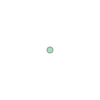

In [14]:
bristol

However, the `Point` class has a number of useful built-in attributes and methods for extracting information - for instance, `Points.wkt` returns a standardised string representation of the point in a standard format known as [Well Known Text (WKT)](https://en.wikipedia.org/wiki/Well-known_text_representation_of_geometry), and `Points.x` and `Points.y` allow us to extract the coordinates independently.

In [5]:
print(bristol.wkt)
print(bristol.x)
print(bristol.y)

POINT (51.46 -2.6)
51.46
-2.6


More attributes and methods are described [in the `shapely` documentation](https://shapely.readthedocs.io/en/stable/manual.html#general-attributes-and-methods).

Note that, in the current form, we have not provided any information about what Coordinate Reference System (CRS) is attached to the geometry: our variable doesn't "know" that the numbers we have provided are in latitude and longitude in units of degrees. They are just arbritrary numbers. Let's create a couple more points before we move on:

In [24]:
bath = Point(-2.36, 51.38)
gloucester = Point(-2.24, 51.86)

### `LineString` data

`LineString` allows points to be connected to each other to create a line. We can do this by passing `LineString` a `list` of `Points`:

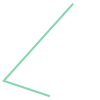

In [25]:
bath_to_gloucester = LineString([bath, bristol, gloucester])

bath_to_gloucester

In [36]:
bath_to_gloucester.wkt

'LINESTRING (-2.36 51.38, -2.6 51.46, -2.24 51.86)'

`LineString` objects have further useful built-in attributes and methods, similar to `Point` objects. For instance, you could retrive the `length` of the line:

In [30]:
bath_to_gloucester.length

0.7911271746964172

As we are working in units of degrees of latitude and longitude, the length will likewise be returned in units of degrees: this is not very useful to us, and it is always better to get features such as `length` (or later, `area`) from CRS systems that work in e.g. metres. However, as `shapely` doesn't know about CRS projections, it will do as you ask, regardless of whether it is correct or not!

We could also calculate the "bounding box": this is a list of coordinates showing the maximum/minimum extent of the feature in the coordinates `(xmin, ymin, xmax ymax)`. 

In [31]:
bath_to_gloucester.bounds

(-2.6, 51.38, -2.24, 51.86)

Or the 'centroid' of the object, the geometric average of the object:

In [34]:
centre = bath_to_gloucester.centroid

centre.wkt

'POINT (-2.439186463636055 51.583254145455776)'

Much of this capability can be directly accessed from a `geopandas` dataframe later.

### `Polygon` data

`Polygon` objects are created in exactly the same manner as `LineString` objects. A minimum of three points need to be passed, and the last point will be connected to the first.

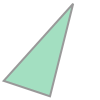

In [33]:
city_polygon = Polygon([bath, bristol, gloucester])

city_polygon

In [35]:
city_polygon.wkt

'POLYGON ((-2.36 51.38, -2.6 51.46, -2.24 51.86, -2.36 51.38))'

Once again, polygons have a series of useful coordinates, such as finding the area or perimeter:

In [ ]:
print(city_polygon.area)

print(city_polygon.length)

print(city_polygon.centroid)

print(city_polygon.bounds)

0.06239999999999957
1.2858998497705334
POINT (-2.4000000000000004 51.56666666666666)


(once again, these values will be returned in degrees, which isn't that useful to us)

`Polgyon`s can also be made more complex - for instance, by adding holes:

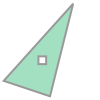

In [44]:
# Create new city polygon with a hole in the middle for an example

poly_centroid = city_polygon.centroid

city_polygon_with_hole = Polygon(
    shell=[bath, bristol, gloucester],
    holes=[[(poly_centroid.x - 0.02, poly_centroid.y - 0.02), (poly_centroid.x + 0.02, poly_centroid.y - 0.02), (poly_centroid.x + 0.02, poly_centroid.y + 0.02), (poly_centroid.x - 0.02, poly_centroid.y + 0.02)]]
)
city_polygon_with_hole

It is also worth pointing out a specific subset of the `Polygon` tool, known as `box`: this creates a rectangular `Polygon` based on a provided `(xmin, ymin, xmax, ymax)` bounding box. As we can generate one for our area, let's do that:

Bounds of the polygon with a hole: (-2.6, 51.38, -2.24, 51.86)


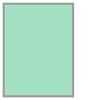

In [63]:
bounds = city_polygon_with_hole.bounds

print(f"Bounds of the polygon with a hole: {bounds}")

bounds_box = box(*bounds)  # `box` accepts four arguments: minx, miny, maxx, maxy, not a single list. `*bounds` unpacks the list into four separate arguments.

bounds_box

### `Multi`- data.

`MultiPoint`, `MultiLineString` or `MultiPolygon` classes allow an individual data variable to contain multiple shapes. For instance:

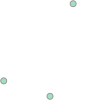

In [46]:
cities_multipoint = MultiPoint([bath, bristol, gloucester])

cities_multipoint

This might be useful in certain circumstances - for instance, imagine you want to define a data frame of countries where each row is a single country. However, countries are rarely a single polygon!

## Geometry operations

There are a variety of interesting geometric operations you can perform on your geometries. For instance, `buffer` expands the geometry by a given value (`Points` and `LineStrings` will turn into `Polygons`):

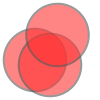

In [52]:
bristol_buffer = bristol.buffer(0.5)
bath_buffer = bath.buffer(0.5)
gloucester_buffer = gloucester.buffer(0.5)

MultiPolygon([bristol_buffer, bath_buffer, gloucester_buffer])

(A similar `erosion` command can make polygons _smaller_ by a given distance!)

`intersection` could return where one polygon overlaps with another:

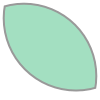

In [54]:
bristol_buffer.intersection(gloucester_buffer)

Whilst `difference` could return only where one polygon does _not_ overlap with another:

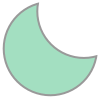

In [55]:
bristol_buffer.difference(gloucester_buffer)

And `union` returns the merged combination:

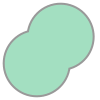

In [57]:
bristol_buffer.union(gloucester_buffer)

If you wish to make very details, the `simplify` tool reduces the number of vertices of a given polygon: 

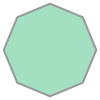

In [68]:
bristol_buffer.simplify(0.1)

## Summary

Once again, this is not an exhaustive list of what can be done with `shapely` commands: it is simply a taster. A complete outline of functionality is available via [the documentation](https://shapely.readthedocs.io/en/stable/index.html), but as usual there's no need to read and digest it all at once. Instead, know that these sort of tools are available to you: when you find yourself needing something similar, you can use your search capabilities to find the solutions your require for your problem.

Now that we understand the core vector data types, we can combine this with our pre-existing Pandas skills using GeoPandas.